In [1]:
%pip install -q diffusers torch-snippets
from torch_snippets import *
from diffusers import DDPMScheduler, UNet2DModel
from torch.utils.data import Subset
import torch  
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

Note: you may need to restart the kernel to use updated packages.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(32),
    torchvision.transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(root="MNIST/", train=True, download=True, transform=transform)
batch_size=128
train_dataloader=DataLoader(dataset,
                            batch_size=batch_size,
                            shuffle=True)

In [5]:
net = UNet2DModel(
    sample_size=128, # the target image resolution
    in_channels=1, # the number of input channels 1 for greyscale
    out_channels=1, # the number of output channels
    layers_per_block=1, # how many ResNet layers tu use per UNet block
    block_out_channels=(32, 64, 128, 256), 
    down_block_types=(
        "DownBlock2D", # a regular ResNet downsampling Block
        "AttnDownBlock2D", # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D", # a ResNet upsampling block with spatial self-attention
        "UpBlock2D", # a regular ResNet Upsampling block
    ),
)

_ = net.to(device)

In [6]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

In [17]:
def corrupt(xb, timesteps=None):
    if timesteps is None:
        timesteps = torch.randint(0, 999, (len(xb),)).long().to(device)
    noise = torch.randn_like(xb)
    noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
    return noisy_xb, timesteps

In [20]:
n_epochs = 2
report = Report(n_epochs)
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(opt, T_max=len(train_dataloader))

In [10]:
for epoch in range(n_epochs):
    n = len(train_dataloader)
    for bx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)
        noisy_x, timesteps = corrupt(x)
        pred = net(noisy_x, timesteps).sample
        loss = loss_fn(pred, x) 
        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step()
        report.record(epoch + ((bx + 1) / n), loss=loss.item(), end='\r')
    report.report_avgs(epoch + 1)

EPOCH: 1.000  loss: 0.043  (1771.65s - 86810.85s remaining)))
EPOCH: 2.000  loss: 0.039  (2632.97s - 63191.40s remaining)
EPOCH: 2.345  loss: 0.036  (2930.91s - 59550.69s remaining)

KeyboardInterrupt: 

101


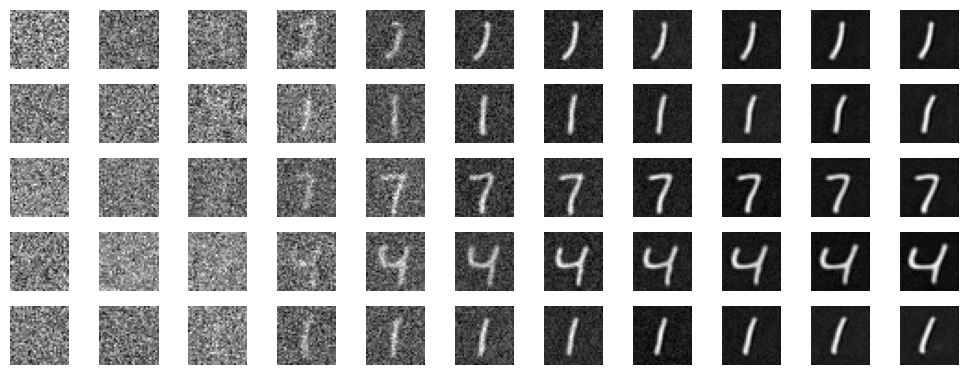

In [19]:
noise = torch.randn(5, 1, 32, 32).to(net.device)
progress = [noise[:, 0]]

for ts in np.logspace(np.log10(999), 0.1, 100):
    ts = torch.Tensor([ts]).long().to(net.device)
    noise = net(noise, ts).sample.detach().cpu()
    noise, _ = corrupt(noise, ts)
    progress.append(noise[:, 0])

print(len(progress))
_n = 10
subplots(torch.stack(progress[::_n]).permute(1, 0, 2, 3).reshape(-1, 32, 32), nc=11, sz=(10, 4))

In [23]:
# conditinal diffusion
class EmbeddingLayer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)

    def forward(self, labels):
        return self.embedding(labels)

In [24]:
embedding_layer = EmbeddingLayer(num_embeddings=10, embedding_dim=32).to(device)

In [26]:
class ConditionalUNet2DModel(UNet2DModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.in_channels += 32 # Adjust for embedding dimension

In [27]:
net = ConditionalUNet2DModel(
    sample_size=128,
    in_channels=1 + 32, # 1 for original image 32 for embedding
    out_channels=1,
    layers_per_block=1,
    block_out_channels=(32, 64, 128, 256),
    down_block_types=("DownBlock2D", "AttnDownBlock2D", 
                      "AttnDownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", 
                    "AttnUpBlock2D", "UpBlock2D"),
).to(device)

C:\Users\chris\AppData\Local\Temp\ipykernel_16368\3462773593.py:4: FutureWarning: Accessing config attribute `in_channels` directly via 'ConditionalUNet2DModel' object attribute is deprecated. Please access 'in_channels' over 'ConditionalUNet2DModel's config object instead, e.g. 'unet.config.in_channels'.
  self.in_channels += 32 # Adjust for embedding dimension


In [31]:
def corrupt_with_embedded_labels(xb, labels, timesteps=None):
    if timesteps is None:
        timesteps = torch.randint(0, 999,
                                  (len(xb),).long().to(device))
    noise = torch.randn_like(xb)
    noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
    labels_embedded=embedding_layer(labels).unsqueeze(1).unsqueeze(-1)
    labels_embedded = labels_embedded.expand(-1, -1, xb.shape[2], xb.shape[3])
    return torch.cat([noisy_xb, labels_embedded], dim=1), timesteps

In [36]:
xb = torch.zeros(10, 1, 32, 32)
timesteps = torch.randint(999, 1000, (len(xb),)).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps).to(device)

In [38]:
labels = torch.Tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]).long().to(device)
labels_embedded = embedding_layer(labels).unsqueeze(-1).unsqueeze(-1)
labels_embedded = labels_embedded.expand(-1, -1, xb.shape[2], xb.shape[3]).to(device)
noisy_x = torch.cat([noisy_xb, labels_embedded], dim=1)

pred = net(noisy_x, timesteps).sample.permute(0, 2, 3, 1).reshape(-1, 32, 32)

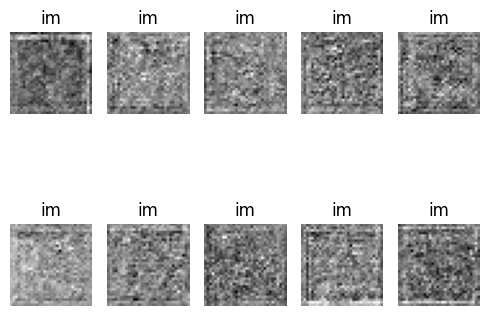

In [39]:
subplots(pred.detach().cpu().numpy())